# Donation forecasting & allocation (CRISP-DM)

## 1. Problem framing
Development and finance teams need **forward-looking views** of giving and how gifts **spread across programs and safehouses**. **Stakeholders:** director of development, program finance, leadership reporting. **Predictive vs explanatory:** **Predictive** models answer “how much / how might allocation look for similar donors?” (generalization to new periods). **Explanatory** Ridge on **log1p(amount)** summarizes **associations** between donor history and amount—useful for narrative slides, not causal claims. **Justification:** Planning is inherently predictive; compliance and storytelling need transparent linear explanations.

## 2. Data acquisition, preparation & exploration
Tables: **`donations`**, **`supporters`**, **`donation_allocations`**, linked by `supporter_id` / `donation_id`. `data_prep.load_donation_tables` and `feature_engineering.build_supervised_rows` construct **time-ordered** rows so each target gift uses only **prior** history (no leakage). Exploration: distributions of amounts, recency/frequency features, allocation shares. **Reproducible pipeline:** `run_all.py`, `export_artifacts.py`, `config.py`.

## 3. Modeling & feature selection
**Amount:** compare algorithms in `train_predictive.train_compare_amount`; **allocation:** `allocation_model.train_allocation_forest`. **Explanatory:** `train_explanatory.run_explanatory`. Features chosen from RFM-style history and categorical supporter fields; selection via regularization and model defaults documented in code.

## 4. Evaluation & interpretation
**Metrics:** RMSE, MAE, R² for amount; allocation errors as appropriate. **Validation:** time-based split. **Business read:** errors mean budget variance—**false high** forecasts can over-commit programs; **false low** leaves capacity unused. Interpret coefficients as **conditional associations**.

## 5. Causal and relationship analysis
Coefficients and importances reflect **correlation structure** (wealth proxies, seasonality, unobserved donor intent). **Not** causal without experiments. **Theoretical plausibility:** past giving predicts future giving; still confounded by macro shocks. Predictive accuracy can coexist with **non-causal** explanations.

## 6. Deployment notes
**Artifacts:** `ml_pipeline_donation_forecasting/serialized_models/*.joblib` + metadata. **Export to .NET:** `refresh_ml_artifacts.py --donors-only` or `ml_backend_export.donors_backend` → `backend/Intex.API/App_Data/ml/donors/`. **UI:** supporter churn / donor ML surfaces in `SupportersListPage.tsx`, ML API `frontend/src/lib/mlApi.ts`, controllers under `backend/Intex.API/Controllers/Ml*.cs`.

**Leakage reminder:** Features use only donations **before** the target gift date; **time-ordered** train/test split.

## 1. Imports & path

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
for p in (HERE, HERE / "ml-pipelines", HERE.parent / "ml-pipelines", HERE.parent):
    if (p / "ml_pipeline_donation_forecasting" / "config.py").is_file():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError("Run from ml-pipelines/ or repo root")

from ml_pipeline_donation_forecasting import config
from ml_pipeline_donation_forecasting.allocation_model import combine_amount_and_allocation, train_allocation_forest
from ml_pipeline_donation_forecasting.data_prep import load_donation_tables, parse_dates
from ml_pipeline_donation_forecasting.dataset_utils import feature_target_columns
from ml_pipeline_donation_forecasting.export_artifacts import export_all
from ml_pipeline_donation_forecasting.feature_engineering import build_supervised_rows
from ml_pipeline_donation_forecasting.train_explanatory import run_explanatory
from ml_pipeline_donation_forecasting.train_predictive import train_compare_amount

config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
config.SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load data & build supervised rows

In [2]:
tabs = parse_dates(load_donation_tables(config.DEFAULT_DATA_DIR))
df, meta = build_supervised_rows(tabs["donations"], tabs["donation_allocations"], tabs["supporters"])
print("rows", len(df), "supporters", meta["n_supporters"])
print(meta["program_areas"])
df[["y_amount", "target_donation_date"]].head()

rows 177 supporters 48
['Education', 'Maintenance', 'Operations', 'Outreach', 'Transport', 'Wellbeing']


,y_amount,target_donation_date
0,663.94,2023-07-01
1,2628.14,2023-12-20
2,1392.10,2024-01-08
3,1042.36,2024-10-17
4,376.97,2024-12-11


## 3. EDA — amount distribution & skew

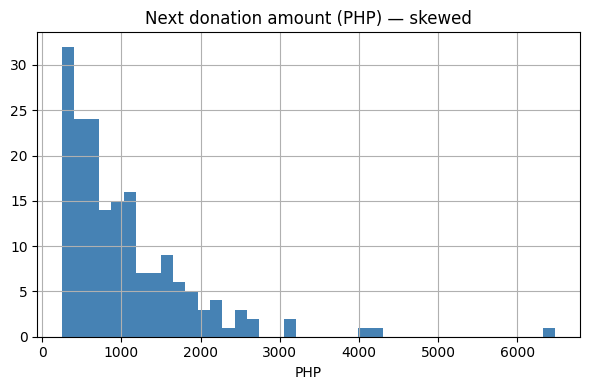

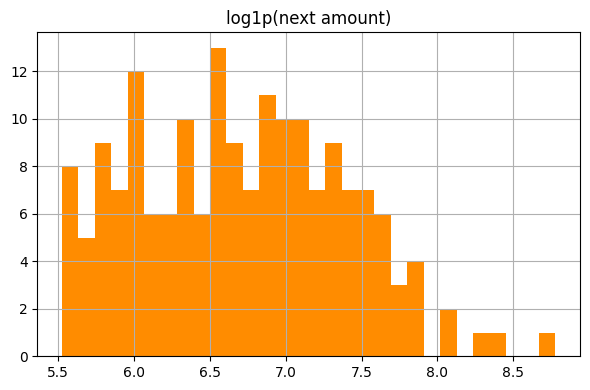

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df["y_amount"].hist(bins=40, ax=ax, color="steelblue")
ax.set_title("Next donation amount (PHP) — skewed")
ax.set_xlabel("PHP")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "fig_amount_hist.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
np.log1p(df["y_amount"]).hist(bins=30, ax=ax, color="darkorange")
ax.set_title("log1p(next amount)")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "fig_log_amount_hist.png", dpi=120)
plt.show()

## 4. Correlation (numeric features only)

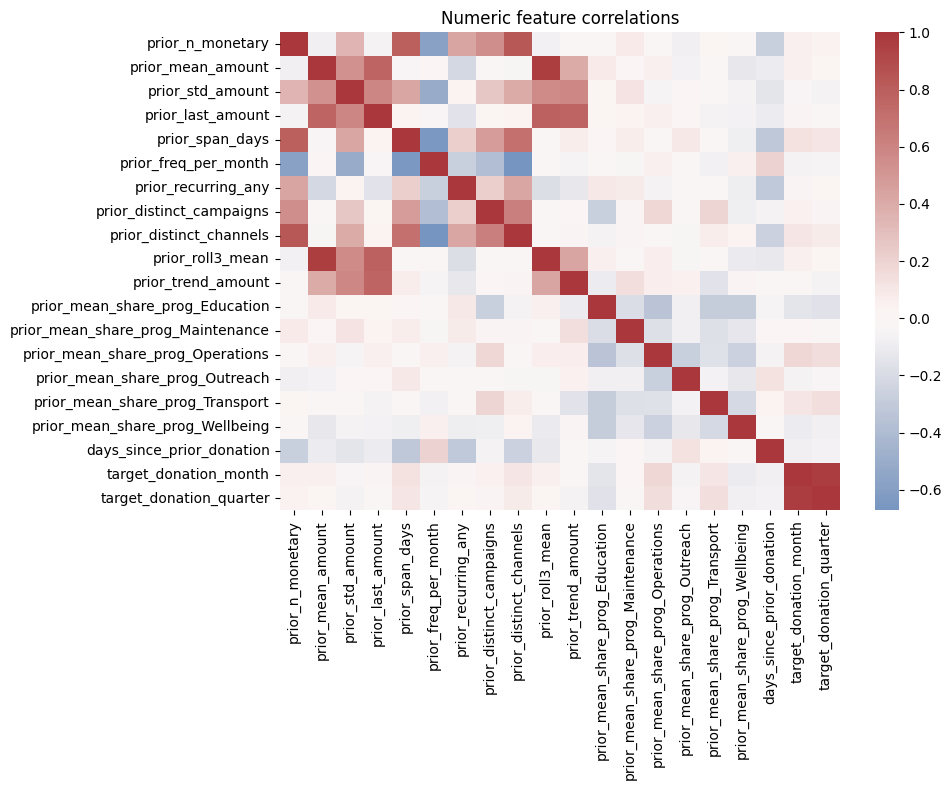

In [4]:
num, cat, _y = feature_target_columns(df, meta)
cm = df[num].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="vlag", center=0)
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "fig_corr.png", dpi=120)
plt.show()

## 5. Allocation vs amount (bivariate)

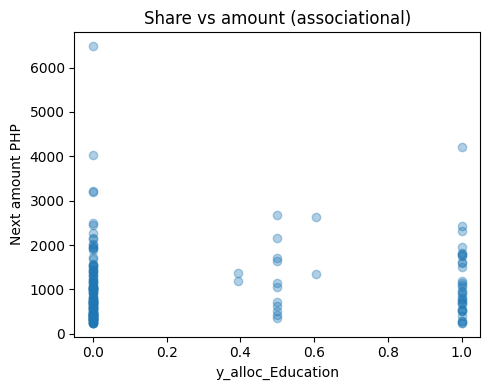

In [5]:
pa = meta["allocation_targets_program"][0]
if pa in df.columns:
    plt.figure(figsize=(5, 4))
    plt.scatter(df[pa], df["y_amount"], alpha=0.35)
    plt.xlabel(pa)
    plt.ylabel("Next amount PHP")
    plt.title("Share vs amount (associational)")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "fig_alloc_vs_amount.png", dpi=120)
    plt.show()

## 6. Explanatory OLS (log amount)

In [6]:
_, coef_df = run_explanatory(df, meta)
display(coef_df.head(20))

,feature,coef,abs_coef
0,intercept,6.709906,6.709906
14,num__prior_mean_share_prog_Operations,0.037138,0.037138
40,cat__sup_acquisition_channel_SocialMedia,0.028408,0.028408
20,num__target_donation_quarter,0.027028,0.027028
3,num__prior_std_amount,0.024465,0.024465
19,num__target_donation_month,0.024232,0.024232
11,num__prior_trend_amount,0.022071,0.022071
2,num__prior_mean_amount,0.020122,0.020122
4,num__prior_last_amount,0.019885,0.019885
41,cat__sup_acquisition_channel_Website,-0.017796,0.017796


## 7. Predictive amount models

In [7]:
amt = train_compare_amount(df, meta)
display(amt["all_results"])
print("Best:", amt["best_name"])

,model,rmse,mae,r2,r2_log,rmse_log,cv_rmse_log_mean,cv_n_splits
0,ridge,812.183852,537.505148,-0.078574,-0.032649,0.675682,NaN,NaN
1,random_forest,803.573504,545.869717,-0.055826,-0.025167,0.673230,0.712111,5.0
2,gradient_boosting,830.359006,638.770832,-0.127387,-0.312411,0.761730,NaN,NaN


Best: random_forest


## 8. Allocation model + combined funding (test rows)

In [8]:
alloc = train_allocation_forest(df, meta, amt["numeric_features"], amt["categorical_features"])
import numpy as np
from ml_pipeline_donation_forecasting.evaluate import regression_metrics
pred_log = np.clip(amt["best_pipeline"].predict(amt["X_test"]), 0, 25)
y_amt_pred = np.expm1(pred_log)
print("Amount holdout:", regression_metrics(amt["y_test"], y_amt_pred))
print("Allocation program MAE:", alloc["program_area_metrics"])
comb = combine_amount_and_allocation(y_amt_pred, alloc["Y_pred"], meta)
print(json.dumps(comb, indent=2))

Amount holdout: {'rmse': 803.5735037032164, 'mae': 545.8697169841458, 'r2': -0.055826333570533127}
Allocation program MAE: {'per_area_mae': {'y_alloc_Education': 0.3860315368419149, 'y_alloc_Maintenance': 0.17806298990207464, 'y_alloc_Operations': 0.3182962590333402, 'y_alloc_Outreach': 0.18593644864789008, 'y_alloc_Transport': 0.22810336613798426, 'y_alloc_Wellbeing': 0.28474286200888305}, 'mean_abs_l1_row': 1.5811734625720875}
{
  "total_predicted_php_sample": 38378.86336496927,
  "predicted_php_by_program_area": {
    "y_alloc_Education": 7003.387829629061,
    "y_alloc_Maintenance": 4861.471950967296,
    "y_alloc_Operations": 10050.246231558971,
    "y_alloc_Outreach": 3938.8112974519017,
    "y_alloc_Transport": 4138.871472344834,
    "y_alloc_Wellbeing": 8386.074583017205
  },
  "predicted_php_by_safehouse": {},
  "note": "Program and safehouse splits are two views of the same predicted gifts; do not add both totals for 'overall budget'."
}


## 9. Export joblib + JSON

In [9]:
info = export_all(df, meta)
print(info)

{'amount_pipeline': PosixPath('/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_donation_forecasting/serialized_models/donation_amount_pipeline.joblib'), 'allocation_pipeline': PosixPath('/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_donation_forecasting/serialized_models/donation_allocation_pipeline.joblib'), 'metadata': PosixPath('/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_donation_forecasting/serialized_models/donation_forecasting_metadata.json'), 'holdout_amount_metrics': {'rmse': 803.5735037032164, 'mae': 545.869716984146, 'r2': -0.055826333570533127}}
